# 🕯️ 海螺水泥 K线与技术分析(第二课)

第一课我们画了折线图,这一课把它升级成**券商研报那种专业图**:

- **K线图(蜡烛图)**:一根蜡烛 = 一天的开盘/收盘/最高/最低,是金融圈最通用的看盘语言
- **成交量副图**:量价配合,技术分析的基本功
- **双均线金叉死叉**:最简单的趋势信号

> 🇨🇳 **A股配色惯例:涨=红,跌=绿**(和欧美相反,别记反了!)
> 阳线(收盘>开盘)=红色,阴线(收盘<开盘)=绿色

In [1]:
# 导入库 + 中文显示设置
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS", "Heiti SC", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 读回第一课的 CSV 数据
df = pd.read_csv("海螺水泥_600585_日K.csv")
print("数据:", df.shape, "个交易日")
df.tail(3)

数据: (483, 7) 个交易日


,date,open,close,high,low,volume,pct_change
480,2026-08-26,17.57,17.88,17.94,17.53,25954100.0,1.59
481,2026-08-27,17.57,18.02,18.05,17.42,41415900.0,0.78
482,2026-08-28,18.00,18.24,18.30,17.84,32647300.0,1.22


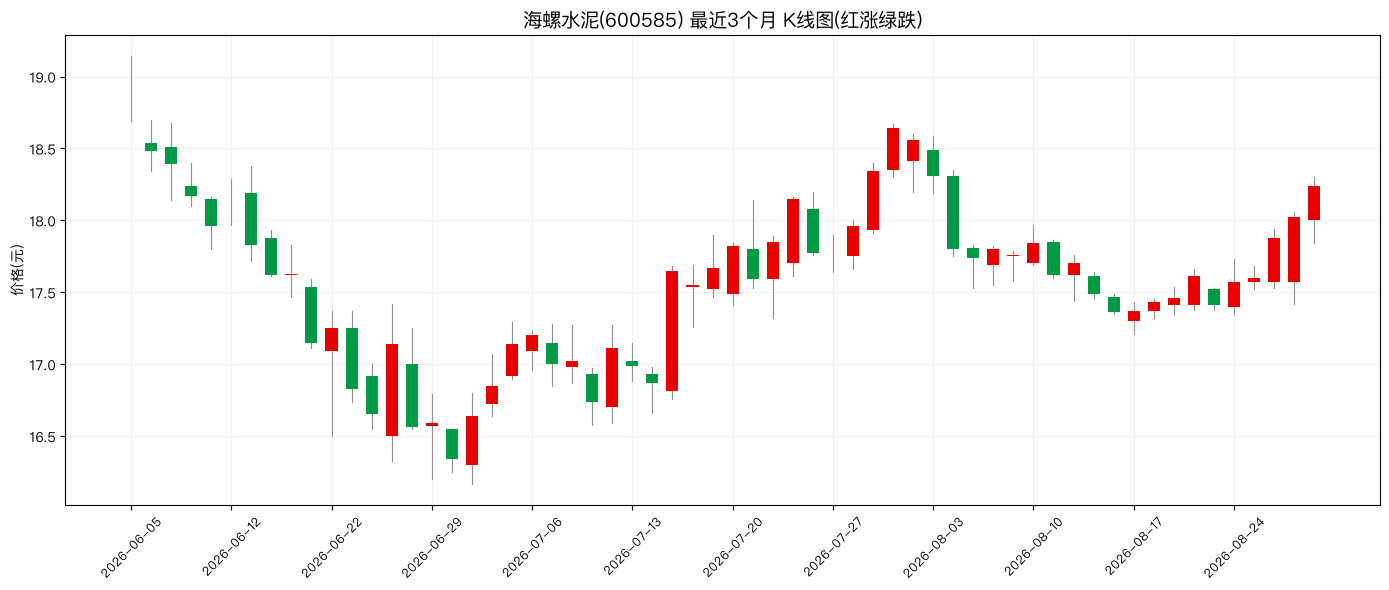

每一根蜡烛:中间实体=开盘到收盘,上下影线=最高和最低


In [2]:
# 定义画 K 线的函数(以后反复用)
def draw_kline(ax, sub, width=0.6):
    """在一张坐标轴上画 K 线。sub 是含 open/close/high/low 的 DataFrame。"""
    for i, (_, r) in enumerate(sub.iterrows()):
        o, c, h, l = r["open"], r["close"], r["high"], r["low"]
        # 影线:从最低到最高的细线
        ax.plot([i, i], [l, h], color="#8c8c8c", linewidth=0.8, zorder=1)
        # 实体:阳线红(涨)、阴线绿(跌)
        color = "#e60000" if c >= o else "#009944"
        bottom, height = (o, c - o) if c >= o else (c, o - c)
        ax.bar(i, height, bottom=bottom, width=width, color=color, zorder=2)
    # 隐藏横向刻度线,只留日期标签(在下面统一设置)

# 取最近 60 个交易日(约3个月)画 K 线
sub = df.tail(60).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))
draw_kline(ax, sub)
ax.set_title("海螺水泥(600585) 最近3个月 K线图(红涨绿跌)", fontsize=14)
ax.set_ylabel("价格(元)")
ax.grid(alpha=0.2)
ticks = range(0, len(sub), 5)
ax.set_xticks(ticks)
ax.set_xticklabels(sub["date"].iloc[ticks], rotation=45, fontsize=9)
plt.tight_layout()
plt.show()
print("每一根蜡烛:中间实体=开盘到收盘,上下影线=最高和最低")

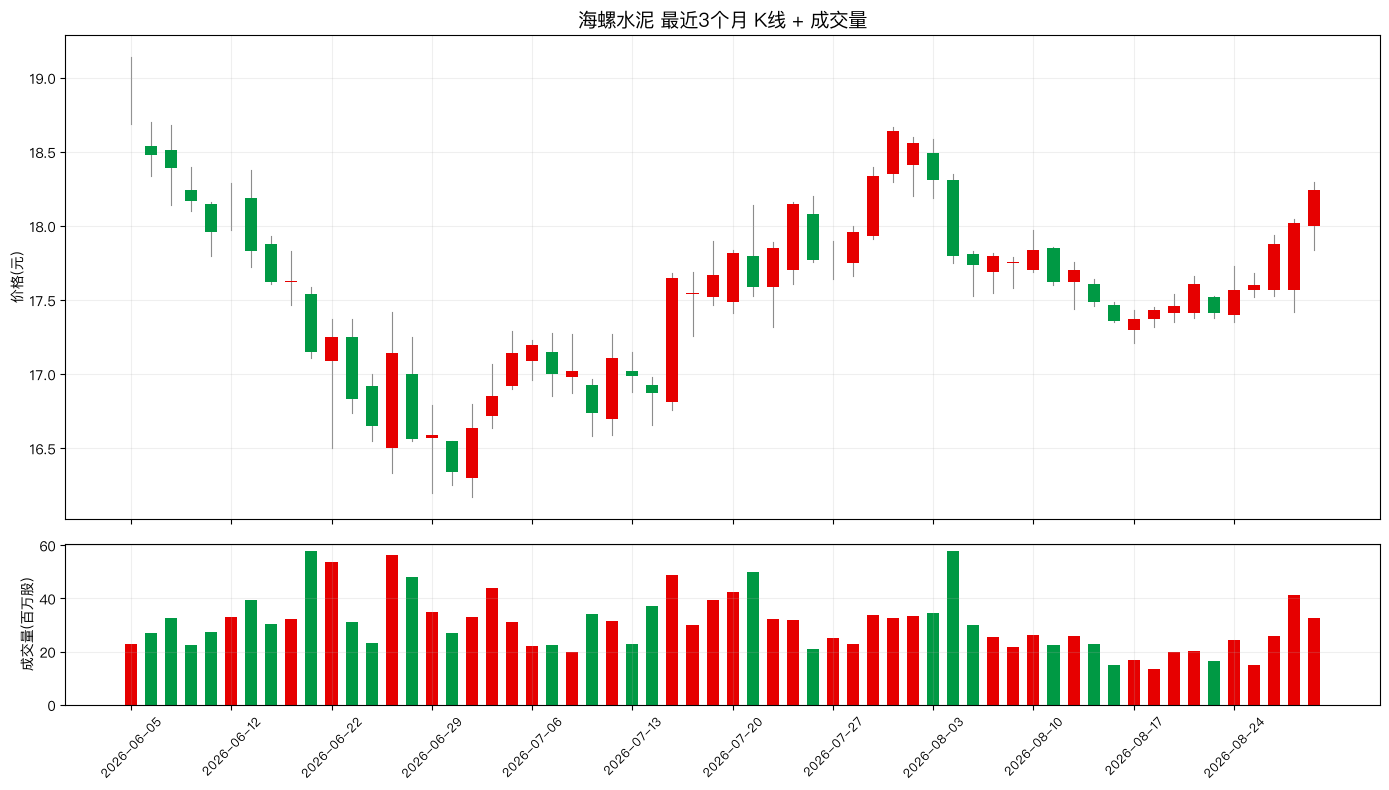

量价配合:放量上涨=资金进场,缩量下跌=抛压减轻


In [3]:
# 经典组合图:K线在上,成交量在下
sub = df.tail(60).reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

# 上图:K线
draw_kline(ax1, sub)
ax1.set_title("海螺水泥 最近3个月 K线 + 成交量", fontsize=14)
ax1.set_ylabel("价格(元)")
ax1.grid(alpha=0.2)

# 下图:成交量(红涨绿跌,和K线颜色一致)
colors = ["#e60000" if c >= o else "#009944" for o, c in zip(sub["open"], sub["close"])]
ax2.bar(range(len(sub)), sub["volume"] / 1e6, color=colors, width=0.6)
ax2.set_ylabel("成交量(百万股)")
ax2.grid(alpha=0.2)

ticks = range(0, len(sub), 5)
ax2.set_xticks(ticks)
ax2.set_xticklabels(sub["date"].iloc[ticks], rotation=45, fontsize=9)
plt.tight_layout()
plt.show()
print("量价配合:放量上涨=资金进场,缩量下跌=抛压减轻")

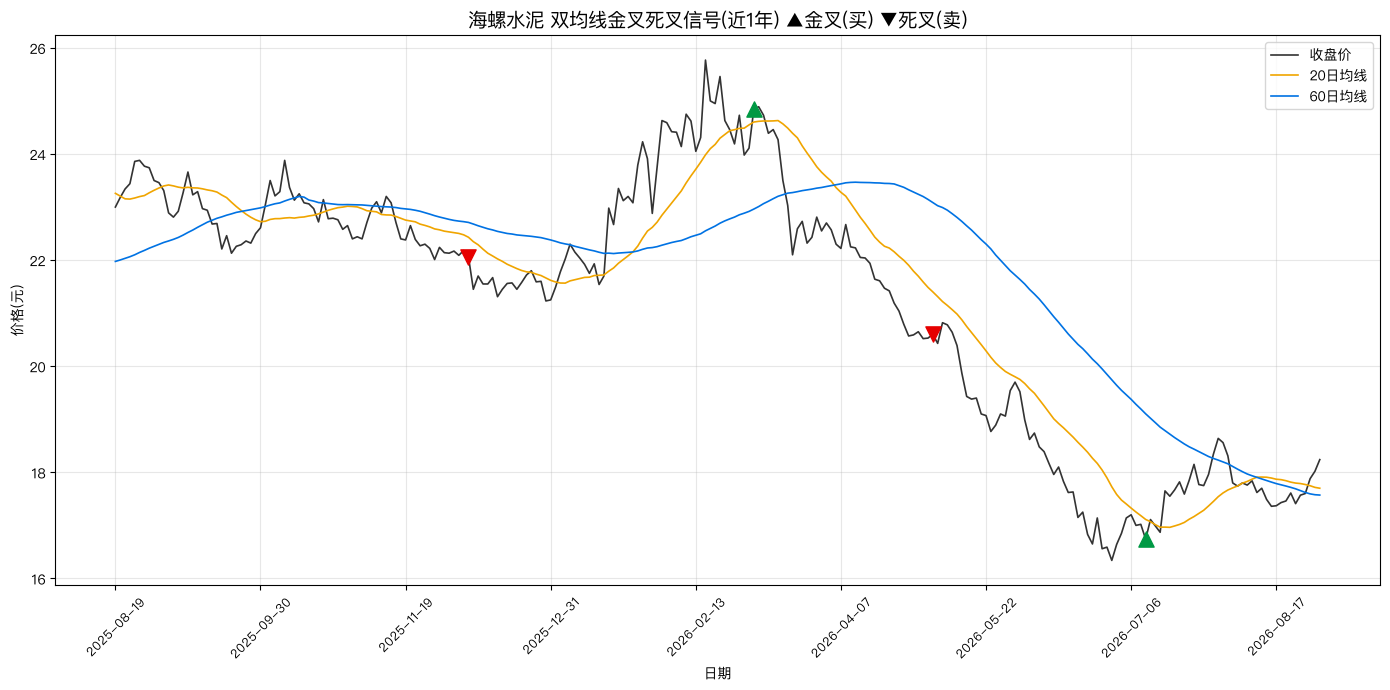

近1年出现 金叉 2 次,死叉 2 次
  金叉日: 2026-03-11
  金叉日: 2026-07-09


In [4]:
# 双均线 + 金叉死叉信号(经典技术分析)
df["MA20"] = df["close"].rolling(window=20).mean()   # 短期均线
df["MA60"] = df["close"].rolling(window=60).mean()   # 长期均线

# 金叉:MA20 从下方上穿 MA60(短期转强,经典买入信号)
# 死叉:MA20 从上方下穿 MA60(短期转弱,经典卖出信号)
diff = df["MA20"] - df["MA60"]
golden = (diff > 0) & (diff.shift(1) <= 0)   # 由负转正 = 金叉
dead   = (diff < 0) & (diff.shift(1) >= 0)   # 由正转负 = 死叉

# 只看最近一年,图更清楚
view = df.tail(250).reset_index(drop=True)
g_idx = [i for i in range(len(view)) if golden.iloc[i]]
d_idx = [i for i in range(len(view)) if dead.iloc[i]]

plt.figure(figsize=(14, 7))
plt.plot(range(len(view)), view["close"], label="收盘价", linewidth=1.2, color="#333333")
plt.plot(range(len(view)), view["MA20"], label="20日均线", linewidth=1.2, color="#f0a500")
plt.plot(range(len(view)), view["MA60"], label="60日均线", linewidth=1.2, color="#0072e3")

# 标注金叉(绿三角朝上)和死叉(红三角朝下)——注意:信号颜色和K线相反,是"买/卖"含义
for i in g_idx:
    plt.scatter(i, view["close"].iloc[i], marker="^", s=120, color="#009944", zorder=5)
for i in d_idx:
    plt.scatter(i, view["close"].iloc[i], marker="v", s=120, color="#e60000", zorder=5)

plt.title("海螺水泥 双均线金叉死叉信号(近1年) ▲金叉(买) ▼死叉(卖)", fontsize=14)
plt.xlabel("日期")
plt.ylabel("价格(元)")
plt.legend()
plt.grid(alpha=0.3)
ticks = range(0, len(view), 30)
plt.xticks(ticks, view["date"].iloc[ticks], rotation=45, fontsize=9)
plt.tight_layout()
plt.show()

print(f"近1年出现 金叉 {len(g_idx)} 次,死叉 {len(d_idx)} 次")
for i in g_idx[:5]:
    print("  金叉日:", view["date"].iloc[i])

## ✏️ 小练习

**题目 1**:把第 3 步的 K 线图改成**只画最近 30 天**(改一个数字就行)。

**题目 2**:在成交量副图里,找出**成交量最大**的那一天是几月几号?那天是涨还是跌?
提示:`sub.loc[sub["volume"].idxmax()]`

**题目 3(进阶)**:假装你按「金叉买入、死叉卖出」交易(每次全仓),在近一年里这个策略一共交易了几次?赚了还是亏了?
提示:用 `golden` 和 `dead` 两个布尔序列,算一下从金叉日收盘价到死叉日收盘价的差。

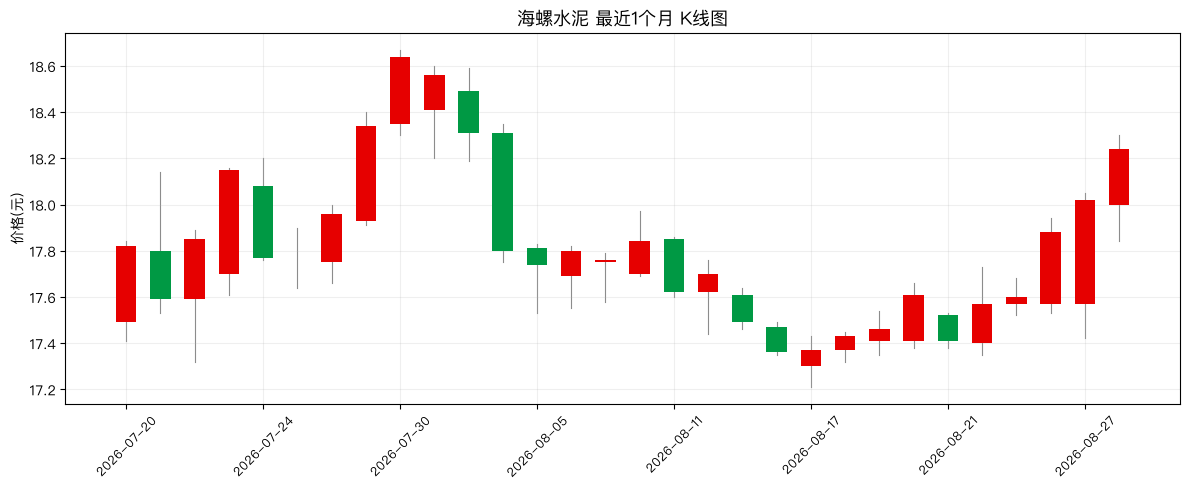

In [5]:
# ✏️ 练习1参考:只画最近 30 天 K 线
sub30 = df.tail(30).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 5))
draw_kline(ax, sub30)
ax.set_title("海螺水泥 最近1个月 K线图", fontsize=13)
ax.set_ylabel("价格(元)")
ax.grid(alpha=0.2)
ticks = range(0, len(sub30), 4)
ax.set_xticks(ticks)
ax.set_xticklabels(sub30["date"].iloc[ticks], rotation=45, fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
# ✏️ 练习2参考:成交量最大的那一天
sub = df.tail(60).reset_index(drop=True)
max_day = sub.loc[sub["volume"].idxmax()]
print("成交量最大的一天:", max_day["date"],
      "成交量", round(max_day["volume"]/1e6, 1), "百万股",
      "涨幅", max_day["pct_change"], "%")

# ✏️ 练习3参考:金叉买、死叉卖 的简单回测(近一年)
view = df.tail(250).reset_index(drop=True)
diff = view["MA20"] - view["MA60"]
golden = (diff > 0) & (diff.shift(1) <= 0)
dead   = (diff < 0) & (diff.shift(1) >= 0)

g_days = view.index[golden].tolist()
d_days = view.index[dead].tolist()

pnl = 0.0
trades = 0
for g in g_days:
    # 找金叉之后最近的一个死叉
    future = [d for d in d_days if d > g]
    if not future:
        continue
    d = future[0]
    pnl += view["close"].iloc[d] - view["close"].iloc[g]
    trades += 1
print(f"策略交易 {trades} 次,按每股算累计盈亏 {pnl:+.2f} 元")
print("(注意:这是最简演示,没算手续费和滑点,真实交易复杂得多)")

成交量最大的一天: 2026-08-04 成交量 57.8 百万股 涨幅 -2.79 %
策略交易 1 次,按每股算累计盈亏 -0.78 元
(注意:这是最简演示,没算手续费和滑点,真实交易复杂得多)
